# Carleton evacuation — DEVS

Set `SCENARIO` (1–10) and `RUN_SIMULATION` below, then **Run All**.

Same layout as the MARS notebook: pick scenario → optional sim → analyze → **inline chart PNGs**.

Outputs go to `results/scenario_XX/` (log + CSVs + PNGs). Step 4 displays the core charts; Step 5 optionally shows `campus_drive_graph.png` when `SHOW_NETWORK_GRAPH` is True.

| # | Scenario |
|---|----------|
| 1 | Baseline |
| 2 | P6 +1 h |
| 3 | P6 +2 h |
| 4 | P3 +1 h, P6 +2 h |
| 5 | P3/P4 +1 h, P6 +2 h |
| 6 | P3/P4 +1 h, P6 +1.5 h |
| 7 | Raven Rd emergency exit (Bronson via r28; P3/P4 prefer) |
| 8 | Bronson & University Dr blocked; Stadium Way open; P1/P2 → SW; P3–P7 → NE |
| 9 | Like 8 + Raven emergency (r28; P3/P4 prefer); no Bronson UD |
| 10 | Baseline topology; all P6 → Colonel By (SW) |

Run this notebook from the DEVS repo root (or WSL), with `bin/campus_evacuation` already built. Scenarios 7–10 require `--scenario` (wired automatically below).

**Step 1** — Load the project folder and helpers for running commands.

In [21]:
from __future__ import annotations

import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path

from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "main" / "main.cpp").is_file():
    for candidate in (ROOT / "model-campus-evacuation-main", ROOT.parent):
        if (candidate / "main" / "main.cpp").is_file():
            ROOT = candidate
            break

os.chdir(ROOT)

BIN = ROOT / "bin" / "campus_evacuation"
RESULTS = ROOT / "results"
SCHEDULES = ROOT / "input_data" / "parking_lot_schedules"


def run_cmd(cmd: list[str], *, quiet: bool = False, label: str | None = None) -> None:
    if label:
        print(label, flush=True)
    elif not quiet:
        print("Running:", " ".join(cmd), flush=True)
    completed = subprocess.run(cmd, cwd=ROOT, capture_output=quiet, text=True)
    if completed.returncode != 0:
        details = ""
        if quiet:
            details = "\n" + (completed.stdout or "") + (completed.stderr or "")
        raise RuntimeError(
            f"Command failed ({completed.returncode}): {' '.join(cmd)}{details}"
        )
    if quiet:
        print("  done.", flush=True)


assert (ROOT / "main" / "main.cpp").is_file(), f"Open this notebook from the DEVS repo root ({ROOT})"
print(f"Ready. Project folder:\n  {ROOT}")

Ready. Project folder:
  /home/doria/Cadmium_Projects/model-campus-evacuation-main


**Step 2** — Pick the scenario and whether to run a new simulation or reuse existing results.

In [22]:
SCENARIO = 8
RUN_SIMULATION = True
BUILD_FIRST = True
SHOW_NETWORK_GRAPH = True  # display campus_drive_graph.png if present

SID = f"{SCENARIO:02d}"
NAME = f"scenario_{SID}"
OUT_DIR = RESULTS / NAME
LOG_PATH = OUT_DIR / f"{NAME}_log.csv"
SCHEDULE = SCHEDULES / f"{NAME}.csv"

assert 1 <= SCENARIO <= 10, f"Choose scenario 1–10 (got {SCENARIO})"
assert SCHEDULE.is_file(), f"Missing schedule: {SCHEDULE}"

print(f"{NAME}  |  run={RUN_SIMULATION}  |  output: {OUT_DIR.relative_to(ROOT)}")

scenario_08  |  run=True  |  output: results/scenario_08


**Step 3** — Build (optional) and run the DEVS / Cadmium simulation (skipped when `RUN_SIMULATION` is False).

Requires Cadmium installed and `bin/campus_evacuation` available (or `BUILD_FIRST = True`).

In [23]:
if RUN_SIMULATION:
    if BUILD_FIRST:
        run_cmd(["bash", "build_sim.sh"], label="Building…")
    if not BIN.is_file():
        raise FileNotFoundError(
            f"Missing binary: {BIN}\nBuild first: bash build_sim.sh  (or set BUILD_FIRST = True)"
        )

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    cmd = [
        str(BIN),
        "-o",
        str(LOG_PATH.relative_to(ROOT)).replace("\\", "/"),
    ]
    # Scenarios 07–10 use dedicated coupled models and/or OD (s07/s09 overrides).
    if SCENARIO in (7, 8, 9, 10):
        cmd.extend(["--scenario", f"scenario_{SID}"])
    else:
        cmd.extend(["-i", str(SCHEDULE.relative_to(ROOT)).replace("\\", "/")])

    run_cmd(cmd, label="Running simulation…")
    if not LOG_PATH.is_file():
        raise FileNotFoundError(f"Simulation finished but log missing: {LOG_PATH}")
    stat = LOG_PATH.stat()
    mtime = datetime.fromtimestamp(stat.st_mtime)
    print(
        f"Log: {LOG_PATH.name}  |  {stat.st_size:,} bytes  |  "
        f"modified {mtime:%Y-%m-%d %H:%M:%S}",
        flush=True,
    )
    print(f"Finished. Output folder: {OUT_DIR.relative_to(ROOT)}", flush=True)
else:
    print("Simulation skipped.")

Building…
-- Building for simulation
-- The C compiler identification is GNU 13.3.0
-- The CXX compiler identification is GNU 13.3.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring done (1.7s)
-- Generating done (0.0s)
-- Build files have been written to: /home/doria/Cadmium_Projects/model-campus-evacuation-main/build
[ 25%] Building CXX object main/CMakeFiles/campus_evacuation.dir/main.cpp.o
[ 50%] Linking CXX executable /home/doria/Cadmium_Projects/model-campus-evacuation-main/bin/campus_evacuation
[ 50%] Built target campus_evacuation
[ 75%] Building CXX object main/CMakeFiles/intersection_test.dir/intersection_te

**Step 4** — Analyze the log and show MARS-aligned summary charts.

Uses `analysis/data_analysis.py` + `analysis/visualize_processed.py` (same pipeline as `run_scenarios.sh`).

Running: /home/doria/Cadmium_Projects/model-campus-evacuation-main/.venv/bin/python3 /home/doria/Cadmium_Projects/model-campus-evacuation-main/analysis/data_analysis.py /home/doria/Cadmium_Projects/model-campus-evacuation-main/results/scenario_08/scenario_08_log.csv --schedule /home/doria/Cadmium_Projects/model-campus-evacuation-main/input_data/parking_lot_schedules/scenario_08.csv
=== Summary ===
Total sim time: 5695.06
Vehicles exited campus: 3200
Vehicles with lot-based time: 3200
Avg evac from t=0: 2120.4376721875
Avg evac from leaving lot: 107.3126721875
Cars/min exiting campus: 33.71342883130292
Schedule: /home/doria/Cadmium_Projects/model-campus-evacuation-main/input_data/parking_lot_schedules/scenario_08.csv (expected=3200)
Exit usage: {'Colonel By': 205, 'Bronson Ave & University Dr': 0, 'Stadium Way': 2795, 'Raven Rd emergency': 200, 'other': 0}
Wrote processed outputs to: /home/doria/Cadmium_Projects/model-campus-evacuation-main/results/scenario_08
Running: /home/doria/Cadmi

### Summary

total_sim_time,exited_count,lot_based_count,avg_from_t0,avg_from_lot,median_from_t0,median_from_lot,cars_per_min,expected,baseline_target
5695.06,3200,3200,2120.4376721875,107.3126721875,1933.815,82.27299999999997,33.71342883130292,3200,3200



### metrics.json

{
  "schema_version": 2,
  "framework": "DEVS",
  "scenario_id": "08",
  "expected": 3200,
  "baseline_target": 3200,
  "completed": 3200,
  "completion_rate_pct": 100.0,
  "total_sim_time_s": 5695.06,
  "mean_drive_to_exit_s": 107.3126721875,
  "median_drive_to_exit_s": 82.27299999999997,
  "mean_exit_from_t0_s": 2120.4376721875,
  "median_exit_from_t0_s": 1933.815,
  "cars_per_min": 33.71342883130292,
  "clearance_by_lot_s": {
    "P1": 2431.18,
    "P2": 916.875,
    "P3": 1024.47,
    "P4": 751.639,
    "P5": 3689.9,
    "P6": 4634.99,
    "P7": 5695.06
  },
  "completed_by_lot": {
    "P1": 100,
    "P2": 100,
    "P3": 200,
    "P4": 100,
    "P5": 700,
    "P6": 900,
    "P7": 1100
  },
  "scheduled_by_lot": {
    "P1": 100,
    "P2": 100,
    "P3": 200,
    "P4": 100,
    "P5": 700,
    "P6": 900,
    "P7": 1100
  },
  "exit_usage": {
    "Colonel By": 205,
    "Bronson Ave & University Dr": 0,
    "Stadium Way": 2795,
    "Raven Rd emergency": 200,
    "other": 0
  }
}


### Charts (`results/scenario_08`)

### Deployment

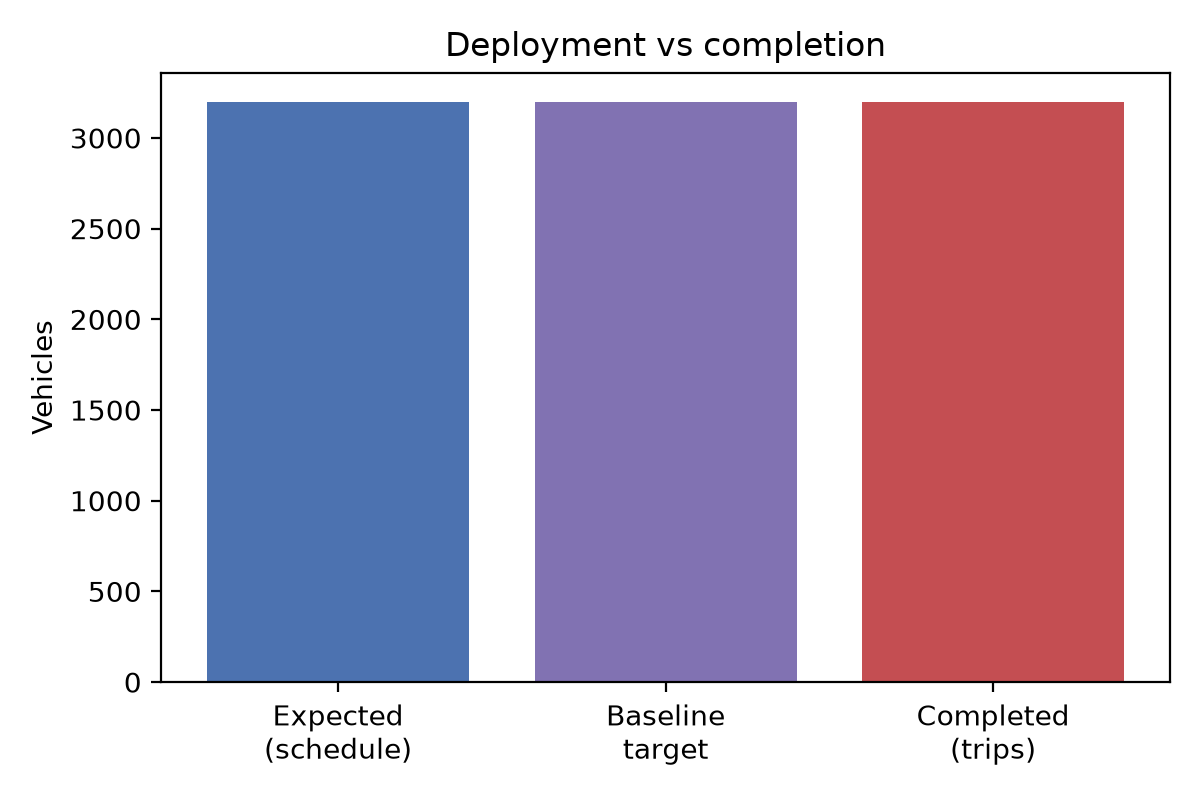

### Evacuation curve

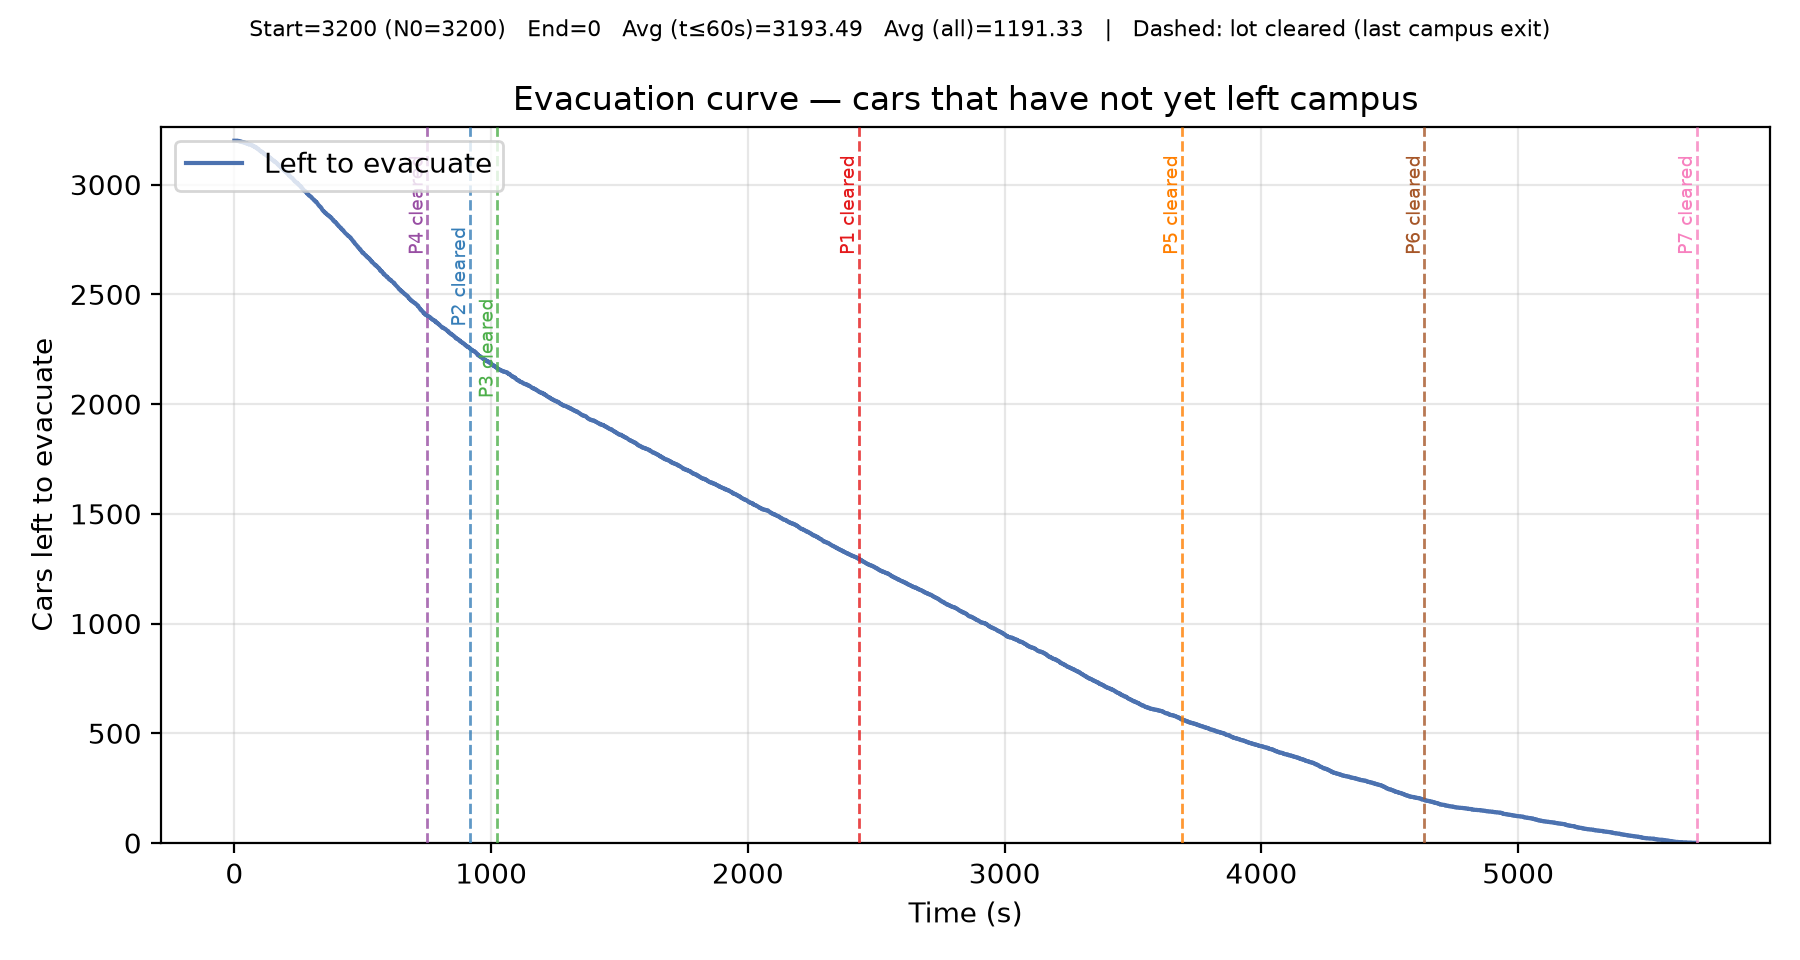

### Travel-time summary

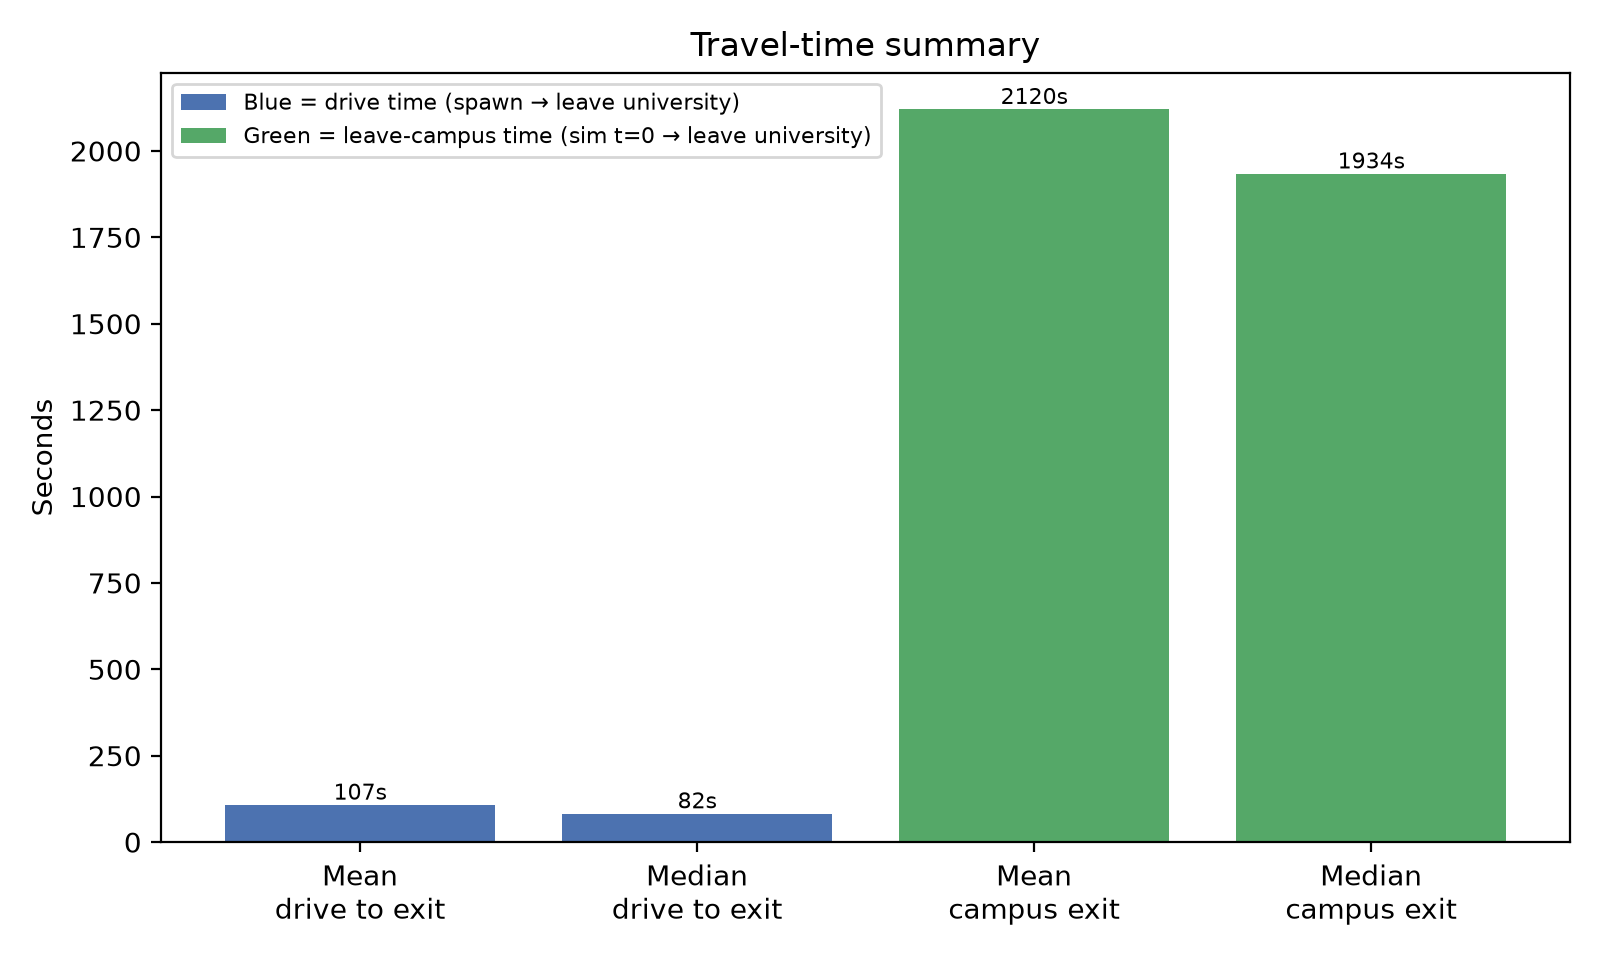

### Travel-time distribution

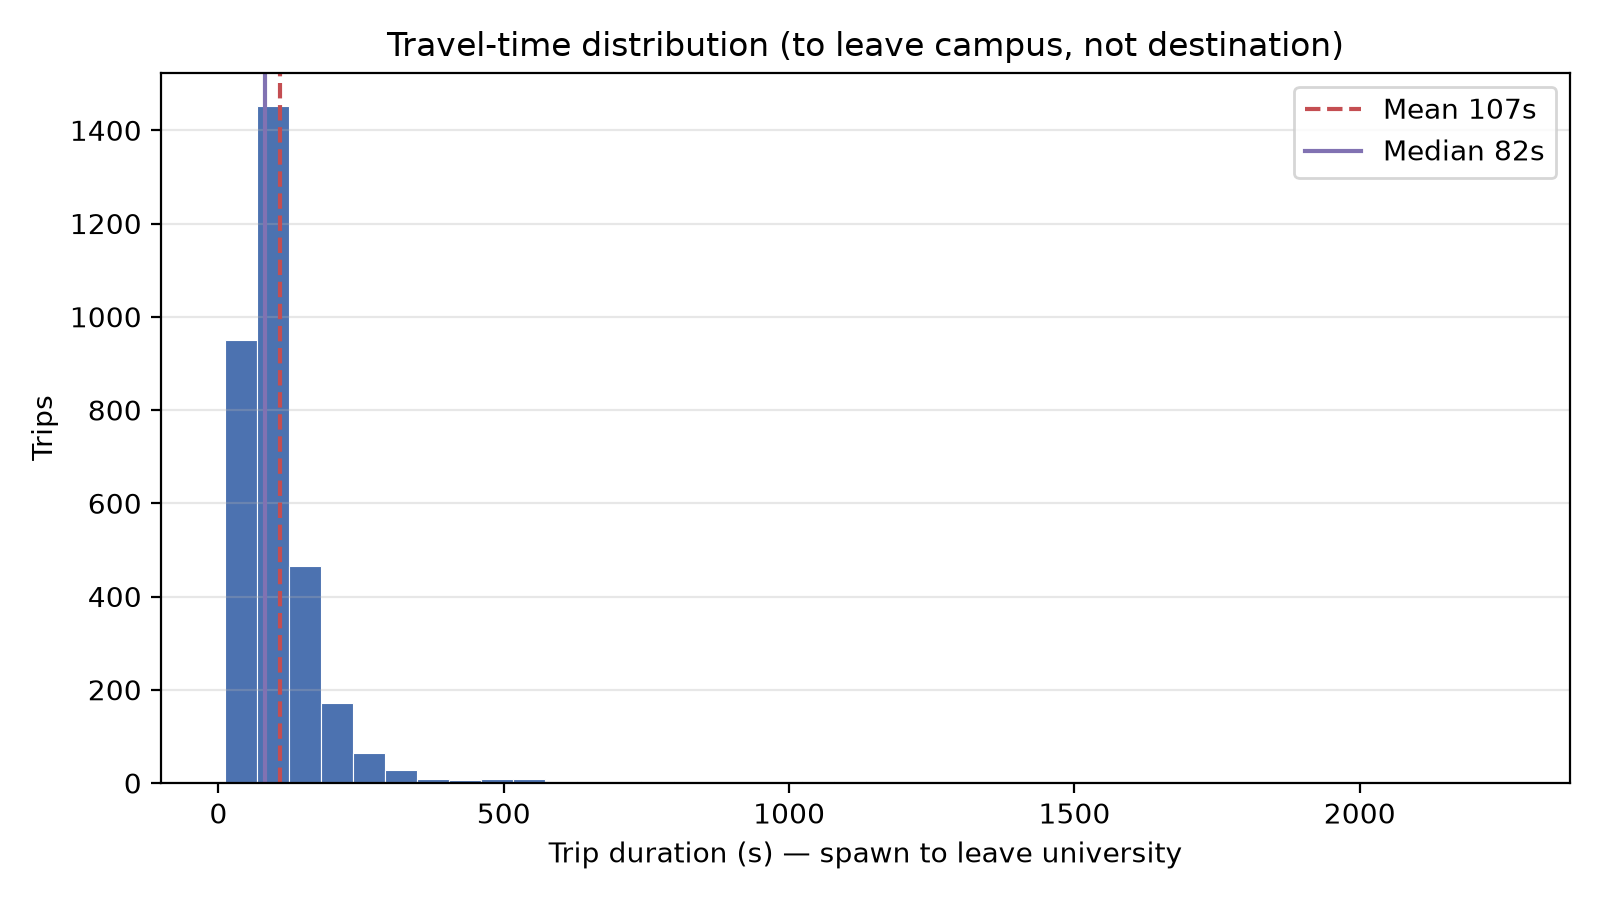

### Clearance by lot

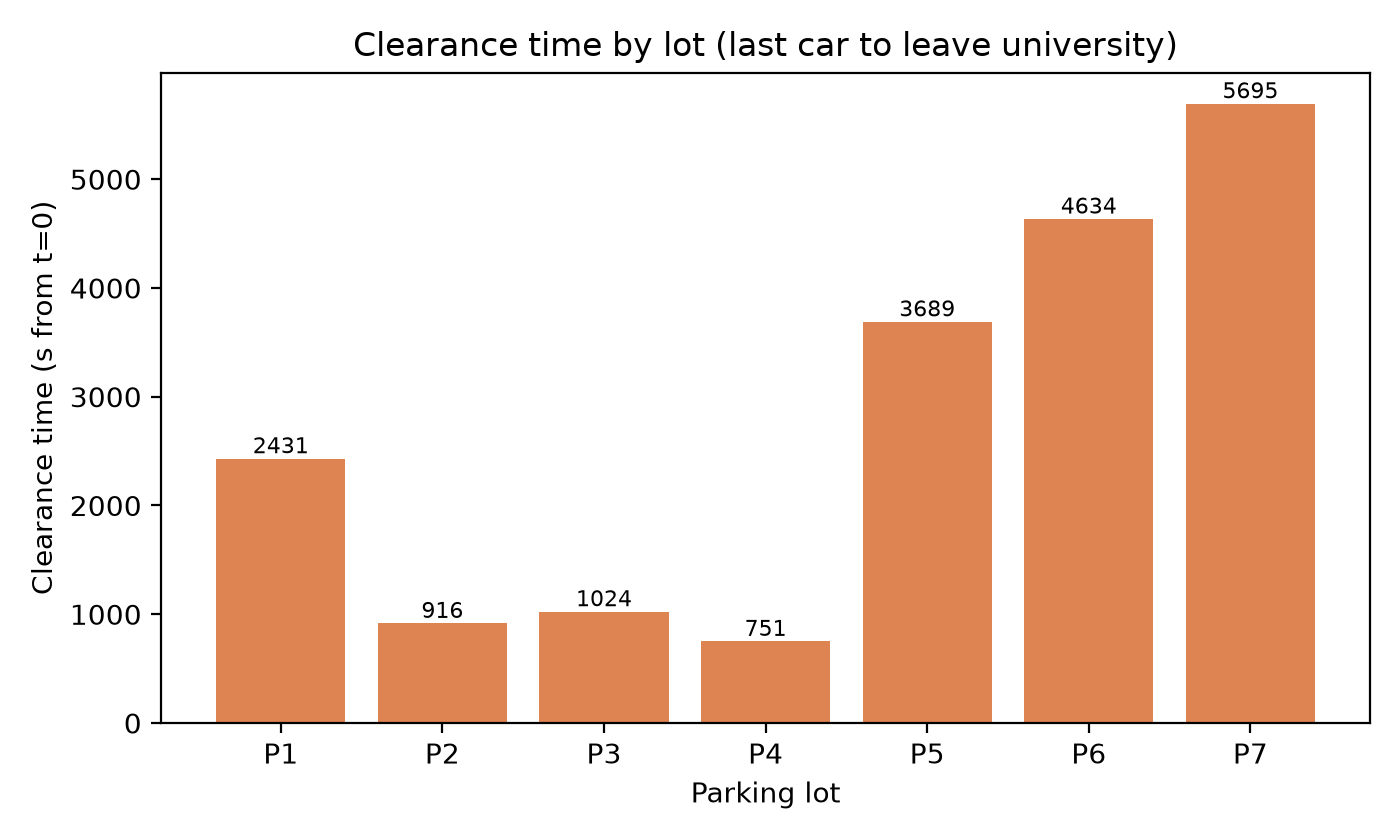

### Per-lot completion

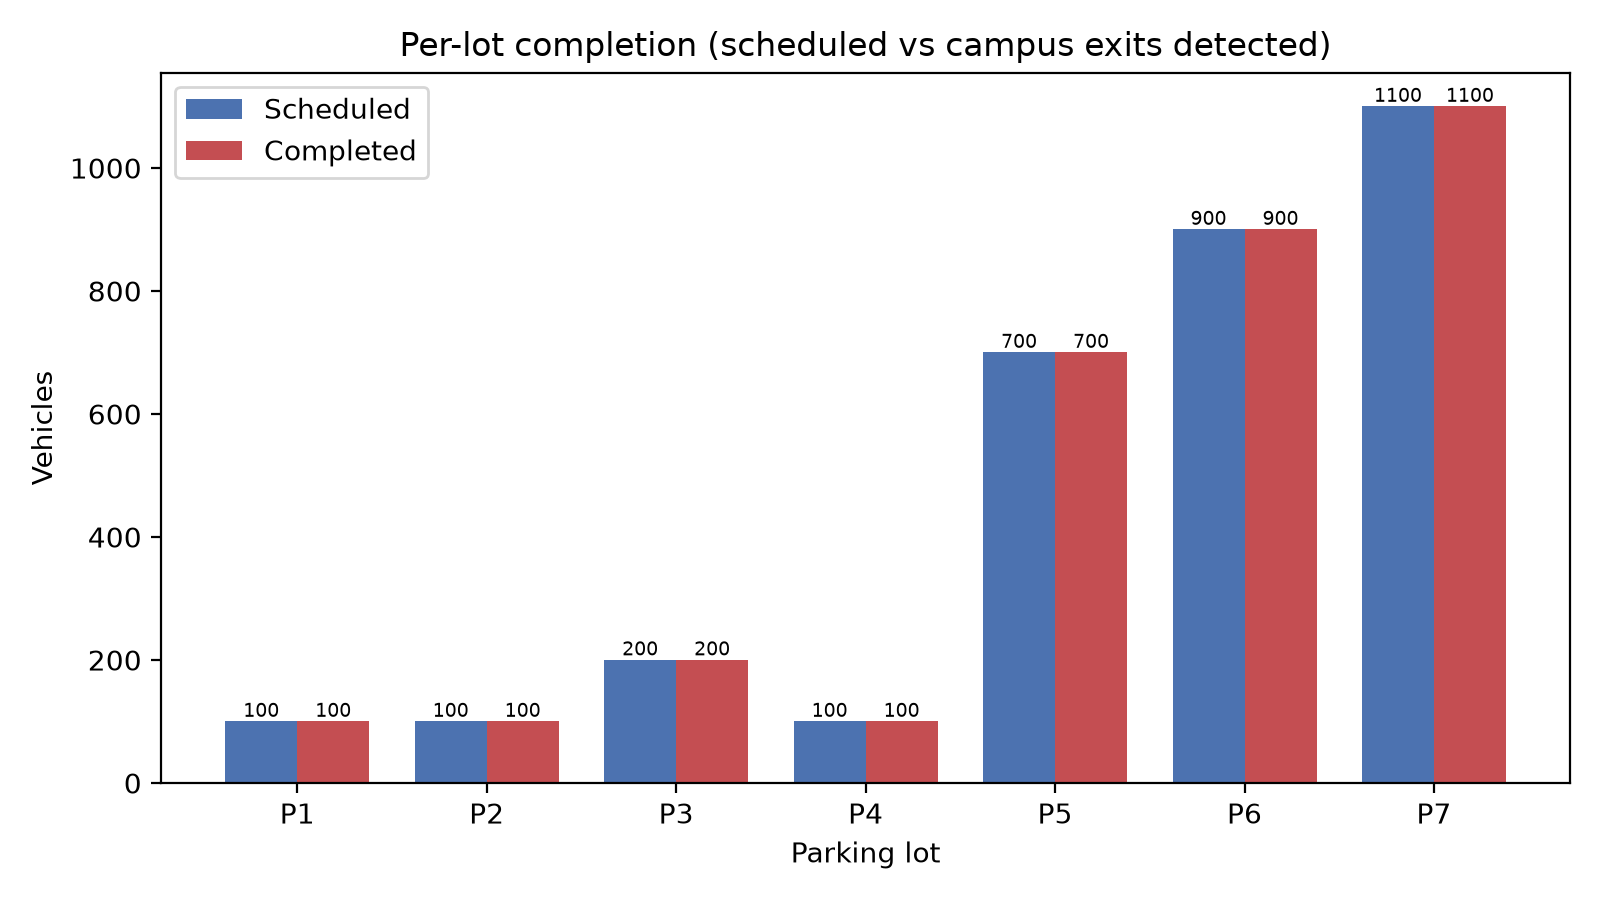

### Exit usage

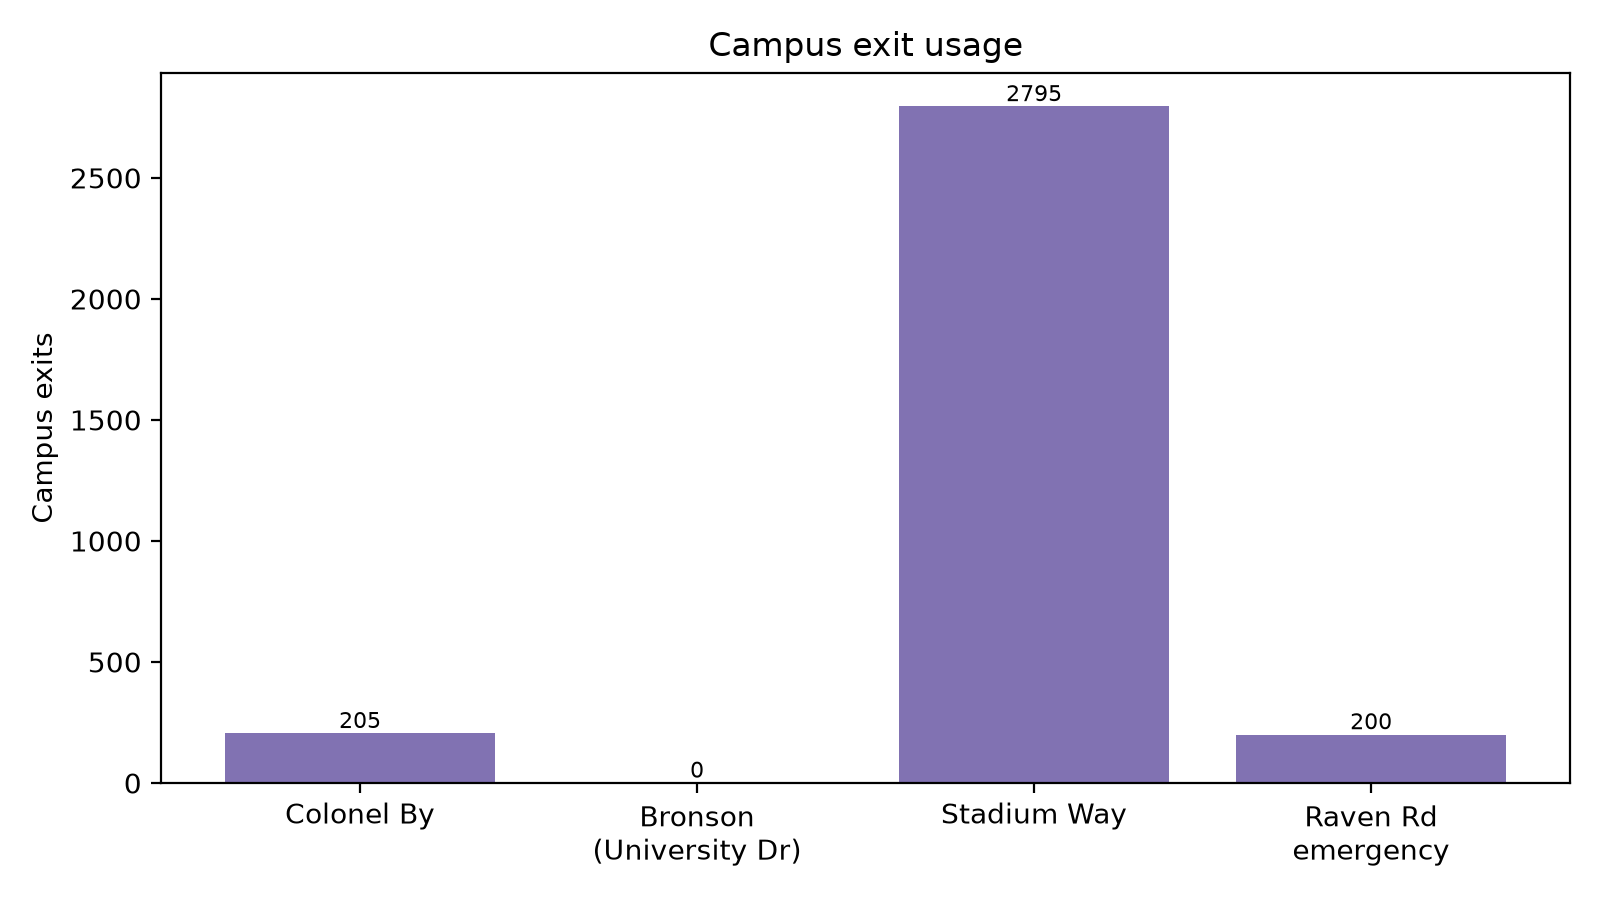

### Heatmap

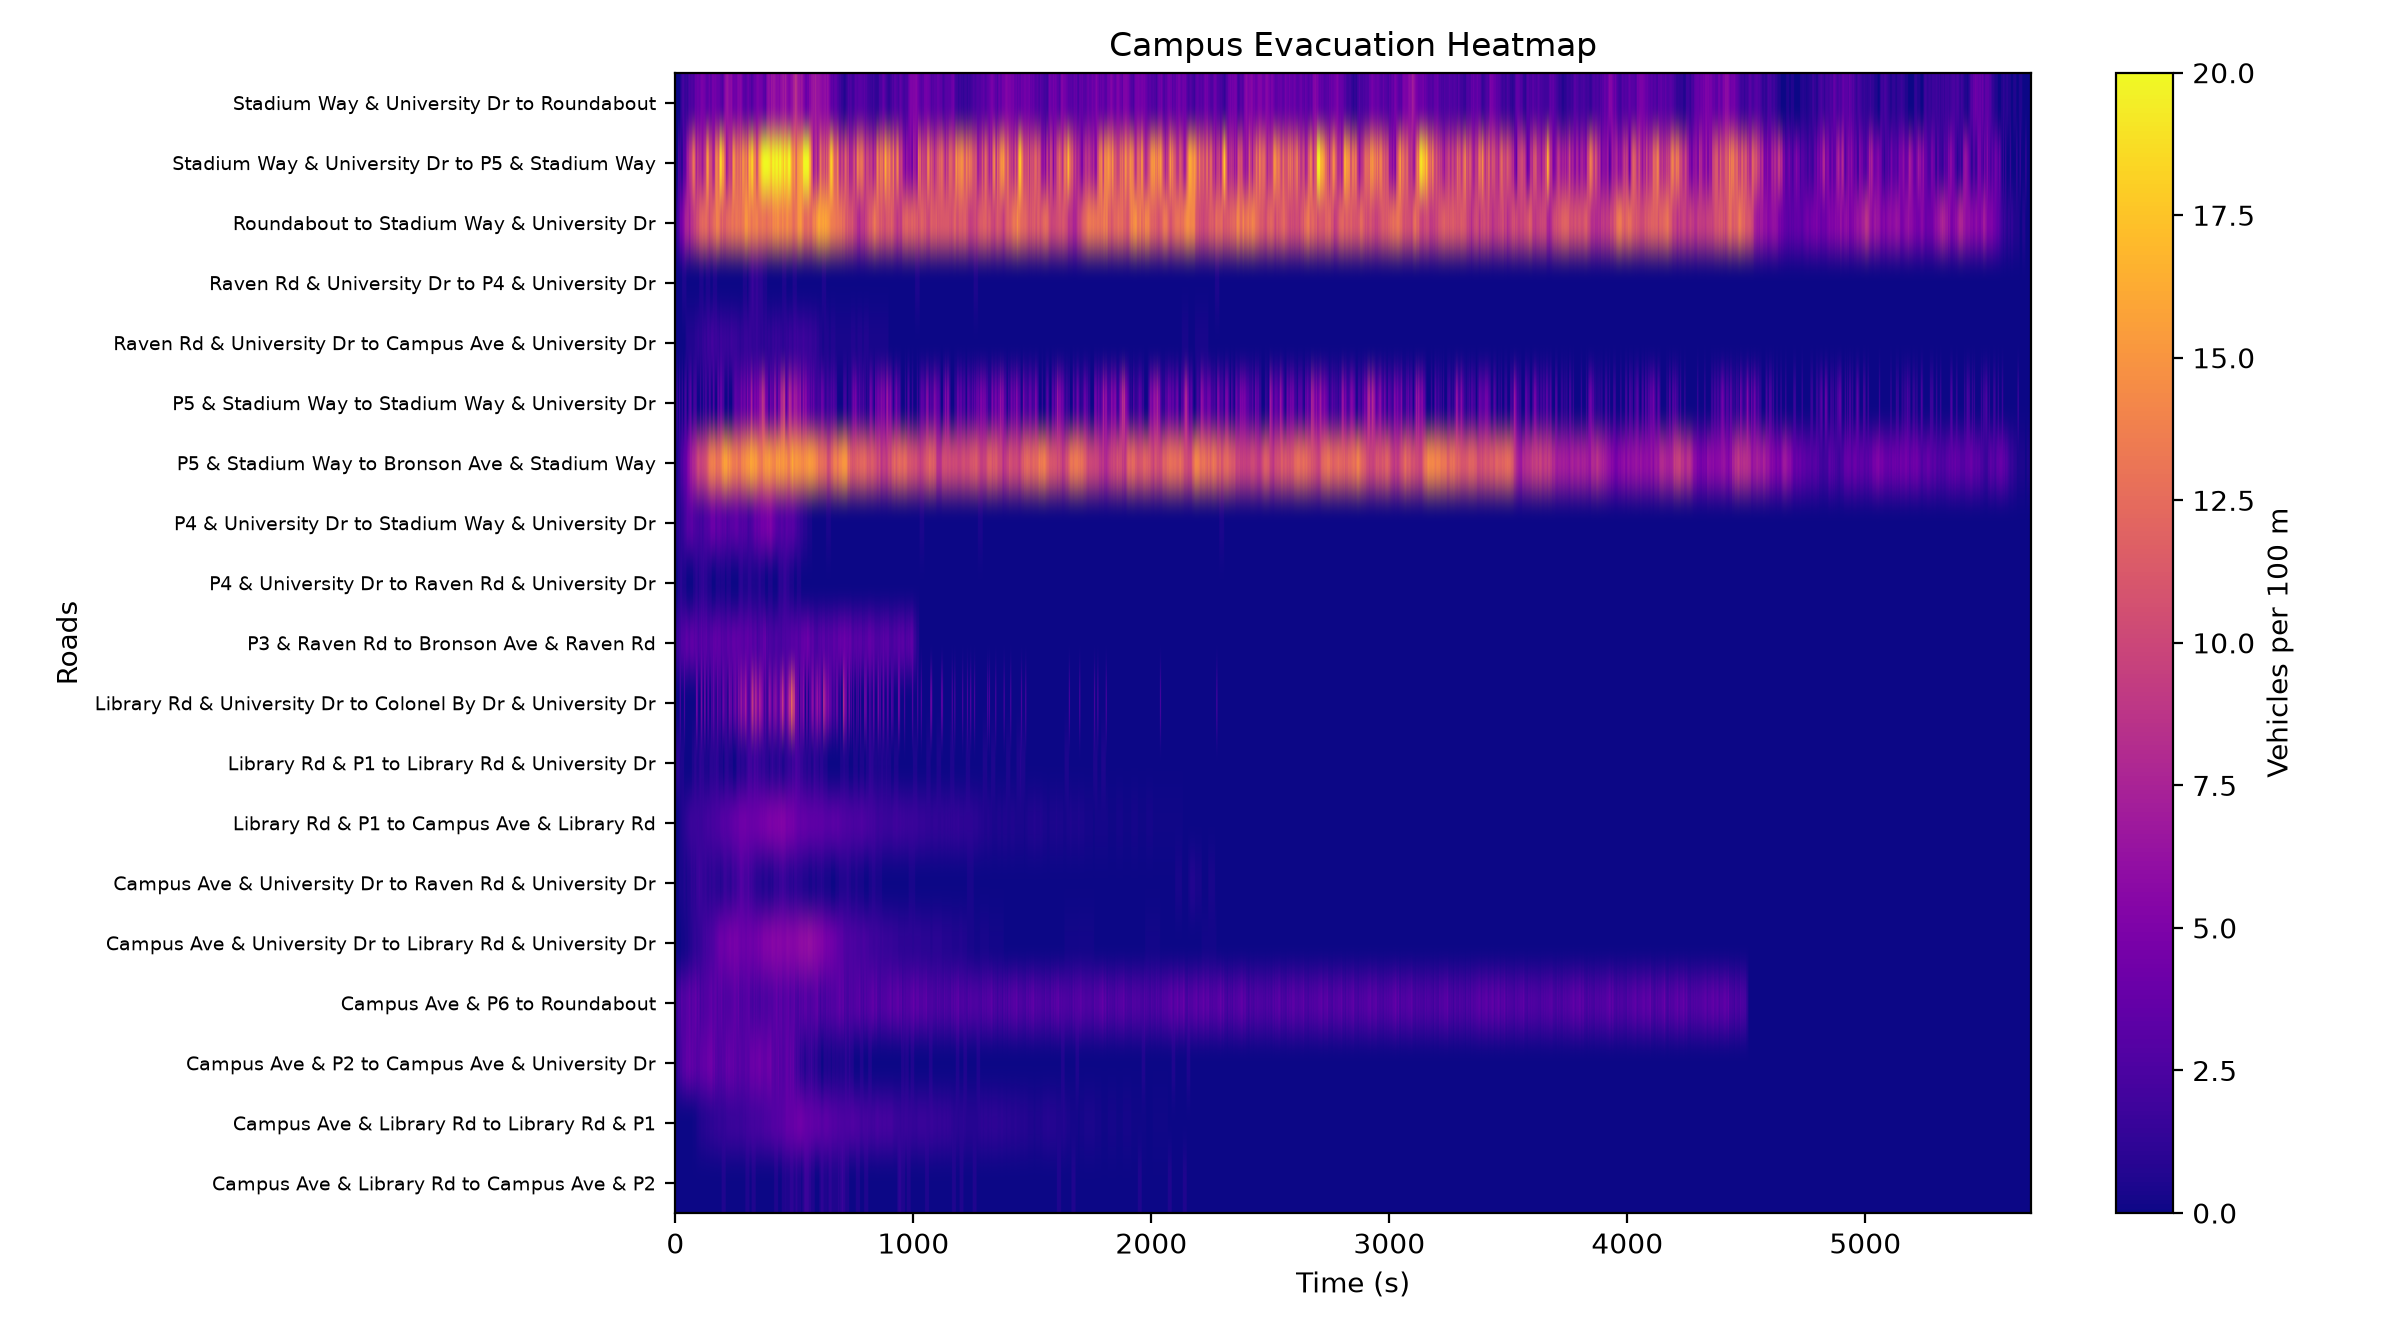

In [24]:
if not LOG_PATH.is_file():
    raise FileNotFoundError(
        f"No log at {LOG_PATH}. Set RUN_SIMULATION = True and re-run Step 3."
    )

OUT_DIR.mkdir(parents=True, exist_ok=True)
py = sys.executable
run_cmd(
    [
        py,
        str(ROOT / "analysis" / "data_analysis.py"),
        str(LOG_PATH),
        "--schedule",
        str(SCHEDULE),
    ]
)
run_cmd([py, str(ROOT / "analysis" / "visualize_processed.py"), str(OUT_DIR)])

summary_csv = OUT_DIR / "summary.csv"
if summary_csv.is_file():
    display(Markdown("### Summary"))
    print(summary_csv.read_text(encoding="utf-8"))

metrics_json = OUT_DIR / "metrics.json"
if metrics_json.is_file():
    display(Markdown("### metrics.json"))
    print(metrics_json.read_text(encoding="utf-8"))

# Core charts (same order as MARS) — display inline from results/scenario_XX/
CHARTS = [
    ("summary.png", "### Deployment"),
    ("evac_curve.png", "### Evacuation curve"),
    ("trip_time_stats.png", "### Travel-time summary"),
    ("trip_time_hist.png", "### Travel-time distribution"),
    ("clearance_by_lot.png", "### Clearance by lot"),
    ("completion_by_lot.png", "### Per-lot completion"),
    ("exit_usage.png", "### Exit usage"),
    ("heatmap_matrix.png", "### Heatmap"),
]

display(Markdown(f"### Charts (`{OUT_DIR.relative_to(ROOT)}`)"))
for name, title in CHARTS:
    path = OUT_DIR / name
    if not path.is_file():
        print(f"Skipping missing chart: {name} (expected at {path})")
        continue
    try:
        display(Markdown(title))
        # Prefer bytes so display works across WSL/Windows kernels
        display(Image(data=path.read_bytes()))
    except Exception as exc:
        print(f"Skipping chart {name}: could not display ({exc})")


**Step 5** — Optional network graph display (`campus_drive_graph.png`).

Skipped when `SHOW_NETWORK_GRAPH` is False, or when the PNG is not in `results/scenario_XX/`.


### Campus drive network

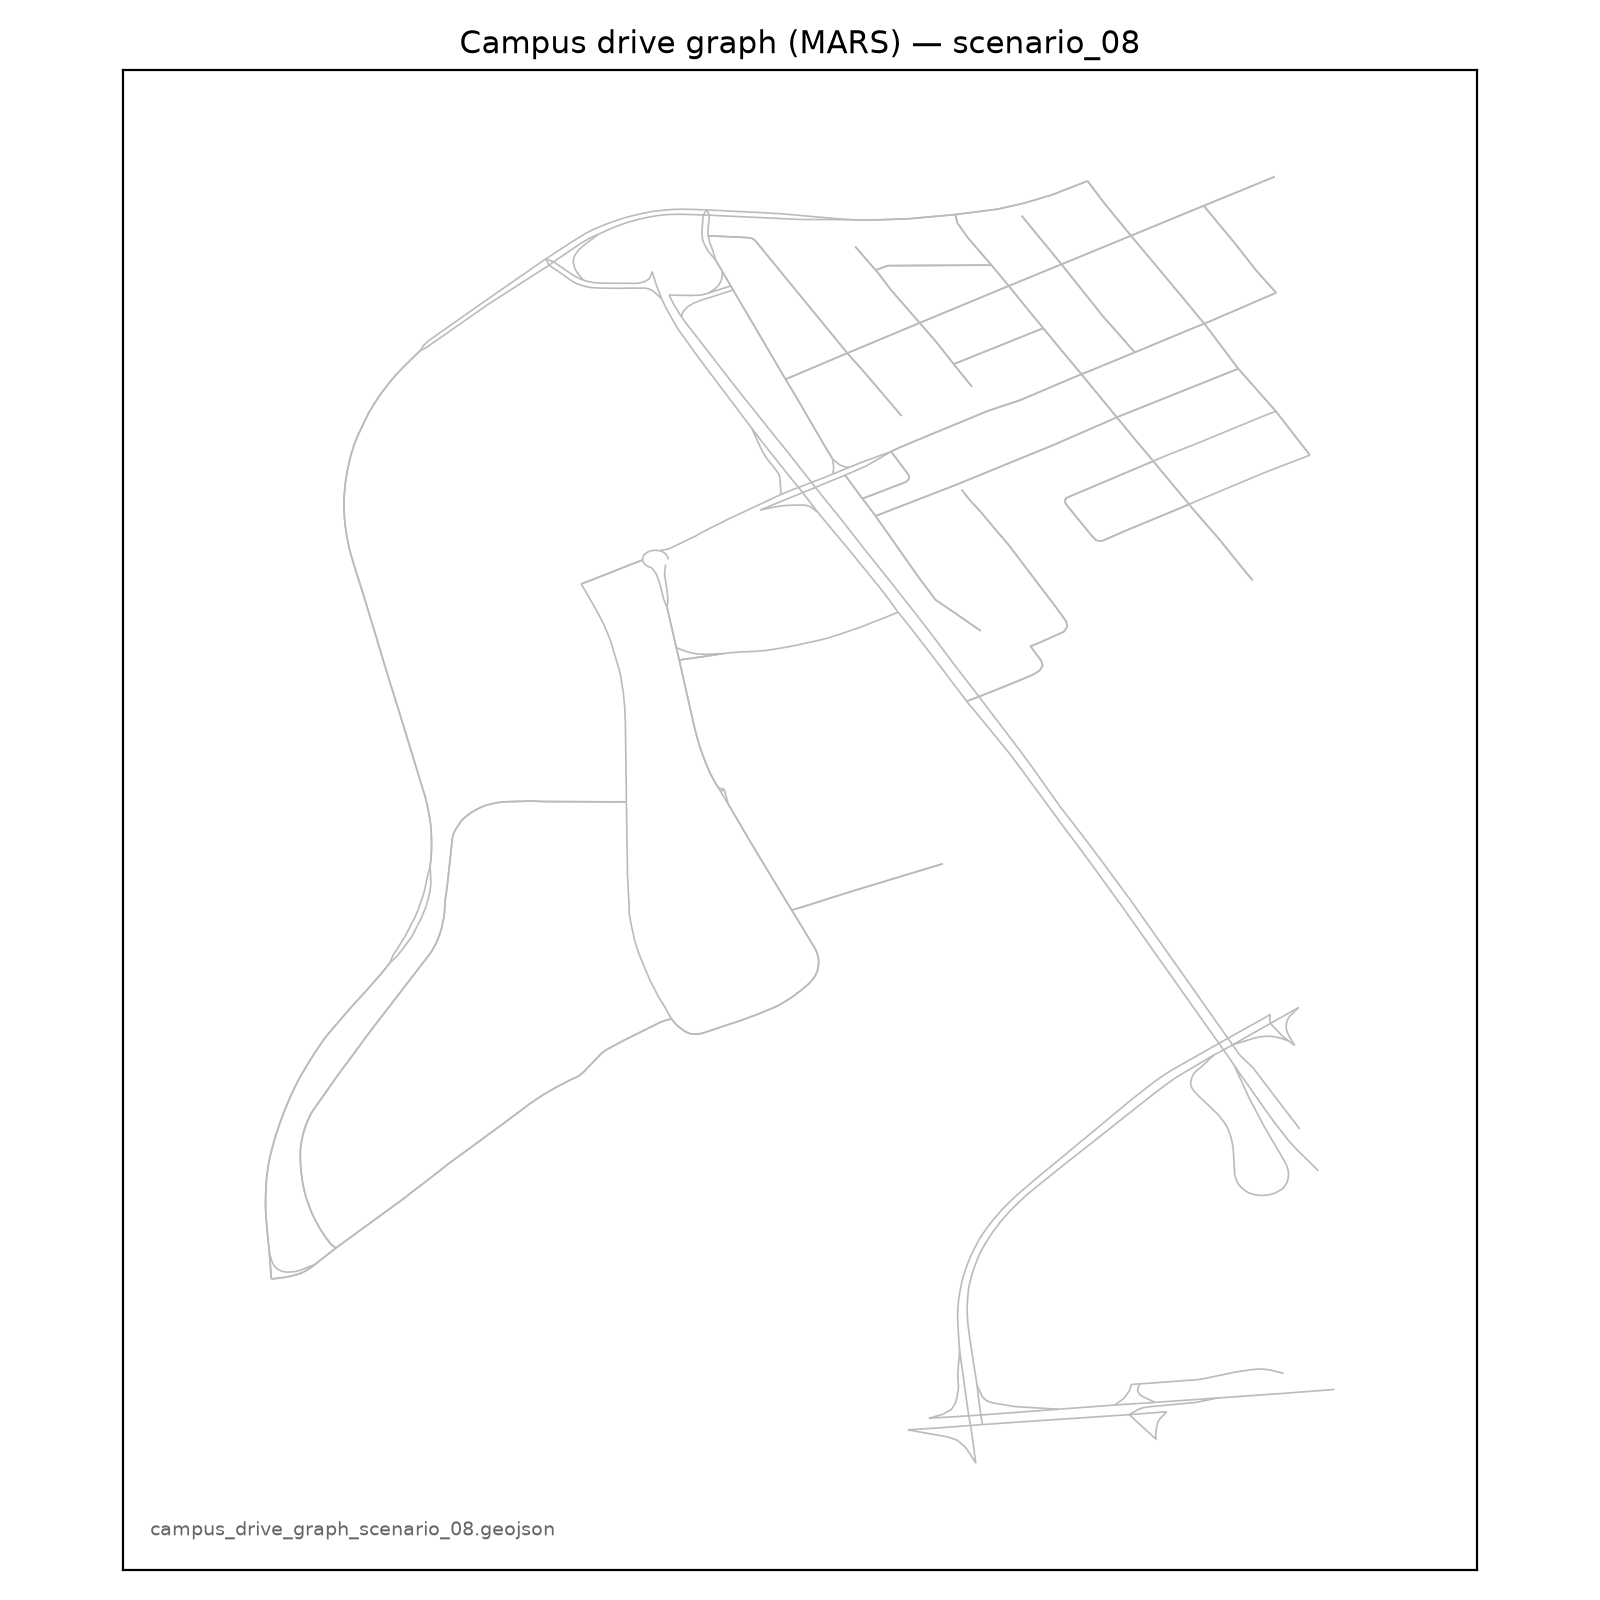

In [25]:
if not SHOW_NETWORK_GRAPH:
    print("Network graph skipped (SHOW_NETWORK_GRAPH is False).")
else:
    path = OUT_DIR / "campus_drive_graph.png"
    if not path.is_file():
        print(f"Skipping missing network graph: {path.name} (expected at {path})")
    else:
        try:
            display(Markdown("### Campus drive network"))
            display(Image(data=path.read_bytes()))
        except Exception as exc:
            print(f"Skipping network graph: could not display ({exc})")
